In [2]:
from scipy.io import loadmat,savemat
from Pub_plots import *
# from Adversarial_training import get_adv_data
from ATKMethods import AlexNetTF
from sklearn.model_selection import train_test_split
import numpy as np
import utils.gestureDataLoader as gestureDataLoader
import tensorflow as tf
import utils.Config as Config
import os
import random
def dict_clean(dict):
    for key in list(dict.keys()):
        if key.startswith('__'):
            del dict[key]
    return dict
def print_asr_acc(info: dict):
    result = {'ASR': [], 'ACC': []}
    for key in info.keys():
        result['ASR'].append(np.mean((info[key][0] - info[key])/info[key][0]))
        result['ACC'].append(info[key][0])
    # info.pop('psr')
    result = pd.DataFrame(result,index = info.keys())
    print(result)
config = Config.getconfig()
if not tf.test.is_gpu_available():
    raise Exception('GPU is not available')

Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.


2023-03-09 09:37:31.474361: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:939] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-03-09 09:37:31.478150: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:939] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-03-09 09:37:31.478246: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:939] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-03-09 09:37:31.489382: I tensorflow/core/platform/cpu_feature_guard.cc:151] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropri

# Adversarial training results

***1. Results path*** 
* PGD attack with l2 norm:
    `resultsMat/acc_all_adv_all_l2_pgd.mat` 
* PGD attack with l-infinite norm:
    `resultsMat/acc_all_adv_all.mat` 
    
Those two the training conducted using L-infinite norm, since if using the l2 norm, the adversarial training will cause invalid gradient (nan or 0) at some point.

* the experiment results with Resnet included
    `resultsMat/acc_all_adv_all_paper_attack_methods`

This results generated by the l2 norm attack, the invaild gradient can be solved by using decorator @tf.funtion

***2. The attacking methods:***
* FGSM, PGD with 2,3,4,5,6,7,12 iterations
  
***3. Defense models training by***
* Normal, FGSM, PGD with 2,3,4,5,6,7,12 iterations



## Comparing Alexnet and Resnet model under adversarial training

* experiment results stored in `resultsMat/adversarial_trainin_alex_resnet.mat`


*** Adversarial training (PSR = 1e-3) method vs Adversarial Attack Method ***

In [ ]:
path = 'resultsMat/adversarial_trainin_alex_resnet.mat'
result = loadmat(path,squeeze_me=True)
result = dict_clean(result)
N = 14
atk = 'fgsm'
info = {
    'psr'           : result['psr'][0:N],
    'Alexnet_FGSM'  : result[f'defult_fgsm_None_0.001_defense_against_{atk}_None'][0:N],
    'Alexnet_PGD'  : result[f'defult_pgd_4_0.001_defense_against_{atk}_None'][0:N],
    # Comparison Results
    # 'resnet_Normal' : result[f'resnet_Normal_None_None_defense_against_{atk}_None'][0:N],
    # 'Alexnet_Normal': result[f'defult_Normal_None_None_defense_against_{atk}_None'][0:N],
    # 'Alexnet_Normal_noise': result['defult_Normal_None_None_defense_against_noise_None'][0:N],
    # 'Resnet_Normal_noise': result['resnet_Normal_None_None_defense_against_noise_None'][0:N],
}
marker_dic = {}
[marker_dic.update({key:marker}) for key,marker in zip(info.keys(),['o','s','^','v','<','>','*','+','x','d'])]
plot_adv_results(config,info,None,'asr',marker_dic = marker_dic)
[print(key,np.mean((info[key][0] - info[key])/info[key][0])) for key in info.keys()]



atk = 'fgsm'
info = {
    'psr'           : result['psr'][0:N],
    'Resnet_FGSM'  : result[f'resnet_fgsm_None_0.001_defense_against_{atk}_None'][0:N],
    'Resnet_PGD'  : result[f'resnet_pgd_4_0.001_defense_against_{atk}_None'][0:N],
    # Comparison Results
    # 'resnet_Normal' : result[f'resnet_Normal_None_None_defense_against_{atk}_None'][0:N],
    # 'Alexnet_Normal': result[f'defult_Normal_None_None_defense_against_{atk}_None'][0:N],
    # 'Alexnet_Normal_noise': result['defult_Normal_None_None_defense_against_noise_None'][0:N],
    # 'Resnet_Normal_noise': result['resnet_Normal_None_None_defense_against_noise_None'][0:N],
}
marker_dic = {}
[marker_dic.update({key:marker}) for key,marker in zip(info.keys(),['o','s','^','v','<','>','*','+','x','d'])]
plot_adv_results(config,info,None,'asr',marker_dic = marker_dic)
[print(key,np.mean((info[key][0] - info[key])/info[key][0])) for key in info.keys()]

atk = 'pgd_4'
info = {
    'psr'           : result['psr'][0:N],
    'Alexnet_FGSM'  : result[f'defult_fgsm_None_0.001_defense_against_{atk}'][0:N],
    'Alexnet_PGD'  : result[f'defult_pgd_4_0.001_defense_against_{atk}'][0:N],
    # Comparison Results
    # 'resnet_Normal' : result[f'resnet_Normal_None_None_defense_against_{atk}_None'][0:N],
    # 'Alexnet_Normal': result[f'defult_Normal_None_None_defense_against_{atk}_None'][0:N],
    # 'Alexnet_Normal_noise': result['defult_Normal_None_None_defense_against_noise_None'][0:N],
    # 'Resnet_Normal_noise': result['resnet_Normal_None_None_defense_against_noise_None'][0:N],
}
marker_dic = {}
[marker_dic.update({key:marker}) for key,marker in zip(info.keys(),['o','s','^','v','<','>','*','+','x','d'])]
plot_adv_results(config,info,None,'asr',marker_dic = marker_dic)
[print(key,np.mean((info[key][0] - info[key])/info[key][0])) for key in info.keys()]

atk = 'pgd_4'
info = {
    'psr'           : result['psr'][0:N],
    'Resnet_FGSM'  : result[f'resnet_fgsm_None_0.001_defense_against_{atk}'][0:N],
    'Resnet_PGD'  : result[f'resnet_pgd_4_0.001_defense_against_{atk}'][0:N],
    # Comparison Results
    # 'resnet_Normal' : result[f'resnet_Normal_None_None_defense_against_{atk}_None'][0:N],
    # 'Alexnet_Normal': result[f'defult_Normal_None_None_defense_against_{atk}_None'][0:N],
    # 'Alexnet_Normal_noise': result['defult_Normal_None_None_defense_against_noise_None'][0:N],
    # 'Resnet_Normal_noise': result['resnet_Normal_None_None_defense_against_noise_None'][0:N],
}
marker_dic = {}
[marker_dic.update({key:marker}) for key,marker in zip(info.keys(),['o','s','^','v','<','>','*','+','x','d'])]
plot_adv_results(config,info,None,'asr',marker_dic = marker_dic)
[print(key,np.mean((info[key][0] - info[key])/info[key][0])) for key in info.keys()]


In [ ]:
result = loadmat('resultsMat/adversarial_trainin_alex_resnet_fineG_5e6to5e2.mat',squeeze_me=True)
result = dict_clean(result)

pp = []
for key in result.keys():
    if 'defult' in key.split('_')[0] and 'pgd' in key.split('_')[1]:
        print(key)
        # pp.append(float(key.split('_')[3]))
print(np.sort(pp))

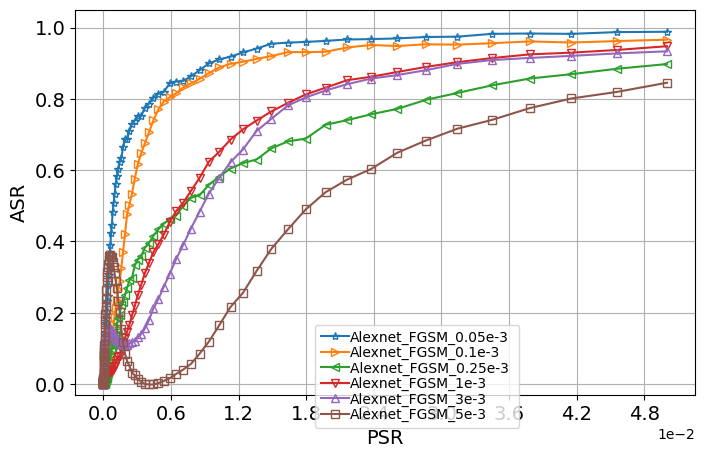

                            ASR       ACC
Alexnet_FGSM_5e-3      0.196327  0.737319
Alexnet_FGSM_3e-3      0.236931  0.923913
Alexnet_FGSM_1e-3      0.227448  0.951087
Alexnet_FGSM_0.25e-3   0.228611  0.893116
Alexnet_FGSM_0.1e-3    0.325844  0.906703
Alexnet_FGSM_0.05e-3   0.418032  0.920290


In [52]:
import pandas as pd
path = 'resultsMat/adversarial_trainin_alex_resnet_fineG_5e6to5e2.mat'
result = loadmat(path,squeeze_me=True)
result = dict_clean(result)
N = 100
atk = 'fgsm_None'
dfs = 'fgsm_None'
info = {
    'psr'           : result['psr'][0:N],
    'Alexnet_FGSM_5e-3'  : result[f'defult_{dfs}_0.005_defense_against_{atk}'][0:N],
    'Alexnet_FGSM_3e-3'  : result[f'defult_{dfs}_0.003_defense_against_{atk}'][0:N],
    'Alexnet_FGSM_1e-3'  : result[f'defult_{dfs}_0.001_defense_against_{atk}'][0:N],
    # 'Alexnet_FGSM_FGSM'  : result[f'defult_{dfs}_0.001_defense_against_{atk}'][0:N],
    # 'Alexnet_PGD_FGSM'  :result['defult_pgd_4_0.001_defense_against_fgsm_None'],
    # 'Alexnet_PGD_PGD'  :result['defult_pgd_4_0.001_defense_against_pgd_4'],
    # 'Alexnet_PGD_Noise'  :result['defult_pgd_4_0.001_defense_against_noise_None']
    # 'Alexnet_FGSM_0.75e-3'  : result[f'defult_fgsm_None_0.00075_defense_against_{atk}'][0:N],
    'Alexnet_FGSM_0.25e-3 '  : result[f'defult_fgsm_None_0.00025_defense_against_{atk}'][0:N],
    'Alexnet_FGSM_0.1e-3'  : result[f'defult_fgsm_None_0.0001_defense_against_{atk}'][0:N],    
    'Alexnet_FGSM_0.05e-3'  : result[f'defult_fgsm_None_5e-05_defense_against_{atk}'][0:N],
}
marker_dic = {}
[marker_dic.update({key:marker}) for key,marker in zip(info.keys(),['o','s','^','v','<','>','*','+','x','d'])]
plot_adv_results(config,info,None,'asr',marker_dic = marker_dic)
print_asr_acc(info)

***Attack by FGSM***

***1. model comparison***

The psr range is :	[0.000e+00 6.250e-05 1.250e-04 1.875e-04 2.500e-04 3.125e-04 3.750e-04
 4.375e-04 5.000e-04 1.000e-03 1.500e-03 3.000e-03 4.000e-03 5.000e-03]


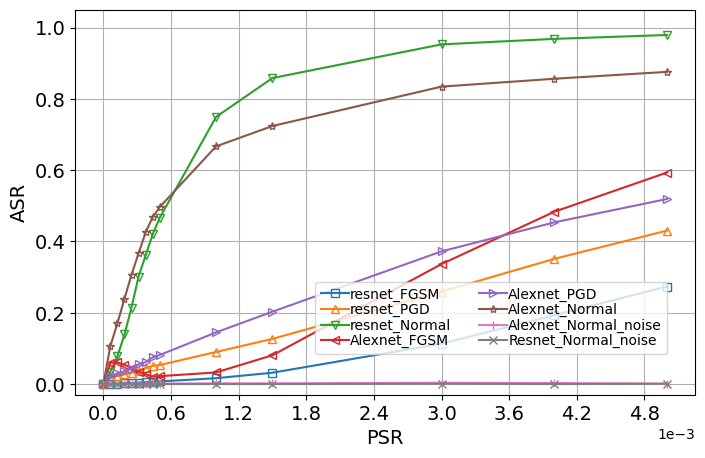

In [15]:
path = 'resultsMat/adversarial_trainin_alex_resnet.mat'
result = loadmat(path,squeeze_me=True)
result = dict_clean(result)
N = 14
atk = 'fgsm'
info = {
    'psr'           : result['psr'][0:N],
    'resnet_FGSM'   : result[f'resnet_fgsm_None_0.001_defense_against_{atk}_None'][0:N],
    'resnet_PGD'    : result[f'resnet_pgd_4_0.001_defense_against_{atk}_None'][0:N],
    'resnet_Normal' : result[f'resnet_Normal_None_None_defense_against_{atk}_None'][0:N],
    'Alexnet_FGSM'  : result[f'defult_fgsm_None_0.001_defense_against_{atk}_None'][0:N],
    'Alexnet_PGD'   : result[f'defult_pgd_4_0.001_defense_against_{atk}_None'][0:N],
    'Alexnet_Normal': result[f'defult_Normal_None_None_defense_against_{atk}_None'][0:N],
    'Alexnet_Normal_noise': result['defult_Normal_None_None_defense_against_noise_None'][0:N],
    'Resnet_Normal_noise': result['resnet_Normal_None_None_defense_against_noise_None'][0:N],
}
print ('The psr range is :',info['psr'],sep='\t')
marker_dic = {}
[marker_dic.update({key:marker}) for key,marker in zip(info.keys(),['o','s','^','v','<','>','*','+','x','d'])]
plot_adv_results(config,info,None,'asr',marker_dic = marker_dic)

# Investigating the impact of PSR in adversarial training

### Impact of the PSR during AT

In [7]:
path =['resultsMat/adversarial_trainin_alex_resnet_fineG_5e6to5e2.mat']
result = {}
for p in path:
    result.update(loadmat(p,squeeze_me=True))
result = dict_clean(result)
info = {}
plt_x_range = np.insert(np.where(result['psr'] > 0.25e-2)[0],0,0)
plt_x_range = np.delete(plt_x_range,(1,2,3,4,6,))
for key in result.keys():
    if key == 'psr':
        info[key] = result[key][plt_x_range]
        continue
    if 'defult' not in key or 'pgd' not in key.split('_')[1] or 'fgsm' not in key.split('_')[6]:
        continue
    at_psr = float(key.split('_')[3])
    if at_psr not in [1e-3,5e-3,0.75e-3,3e-3]:
        continue
    AT_psr = key.split('_')[3]
    AT_method = key.split('_')[1]
    ATK_method = key.split('_')[6]
    # legend = f'Alexnet_{AT_method}_{AT_psr}_defense_{ATK_method}'
    info[key] = result[key][plt_x_range]
    print(key,result[key][0],sep='\t')
info ['Regular'] = result['defult_Normal_None_None_defense_against_fgsm_None'][plt_x_range]

legend = {}
legend['Regular'] = 'Regular'
legend['defult_fgsm_None_0.00075_defense_against_fgsm_None'] = 'FGSM $0.75 * 10^{-3}$'
legend['defult_fgsm_None_0.005_defense_against_fgsm_None'] = 'FGSM $5 * 10^{-3}$'
legend['defult_fgsm_None_0.003_defense_against_fgsm_None'] = 'FGSM $3 * 10^{-3}$'
legend['defult_fgsm_None_0.001_defense_against_fgsm_None'] = 'FGSM $1 * 10^{-3}$'

marker_dic = {}
[marker_dic.update({key:marker}) for key,marker in zip(info.keys(),['o','s','^','v','<','>','*','+','x','d'])]
# plot_adv_results(config,info,None,'asr',marker_dic = marker_dic,legend = legend)

defult_pgd_4_0.001_defense_against_fgsm_None	0.85144925


[None, None, None]

### Defense capability of different methods

In [38]:
def filters(key):
    try:
        bool_flag = []
        bool_flag.append(key != 'psr')
        bool_flag.append('defult' in key)
        bool_flag.append('Normal' in key.split('_')[1])
        return all(bool_flag)
    except:
        return False
for key in result.keys():
    flag = filters(key)
    print(key) if flag else None

defult_Normal_None_None_defense_against_fgsm_None
defult_Normal_None_None_defense_against_pgd_4
defult_Normal_None_None_defense_against_pgd_6
defult_Normal_None_None_defense_against_pgd_8
defult_Normal_None_None_defense_against_noise_None
defult_Normal_None_None_defense_against_pgd_10
defult_Normal_None_None_defense_against_pgd_16
defult_Normal_None_None_defense_against_deepfool


<Figure size 800x600 with 0 Axes>

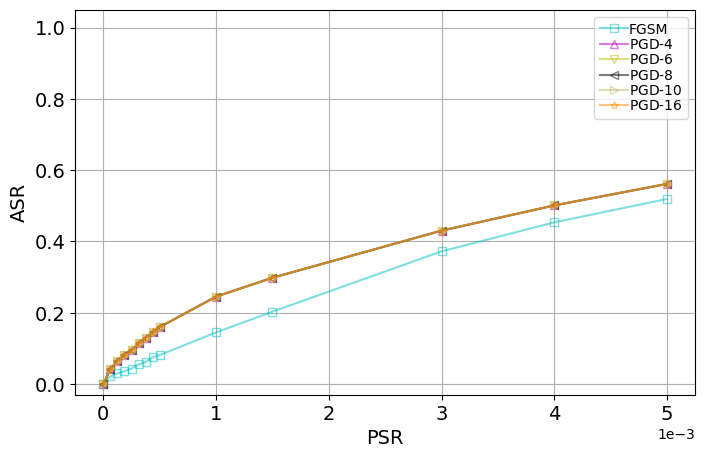

<Figure size 800x600 with 0 Axes>

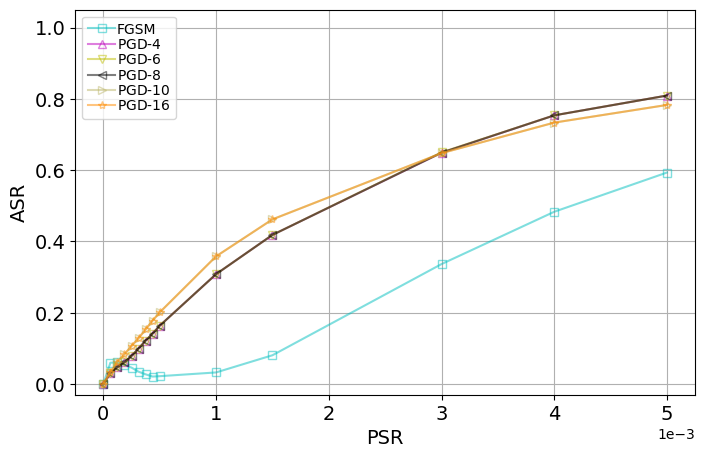

In [3]:

path =['resultsMat/adversarial_trainin_alex_resnet.mat','resultsMat/robust_model_against_deepfool.mat']
result = {}
for p in path:
    result.update(loadmat(p,squeeze_me=True))
result = dict_clean(result)

Defender = ['pgd','Normal']
i_DFS = 4
attacker = ['fgsm','pgd','deepfool','noise']
i_ATK = ['None',4,6,8,10,16]

# rg = np.asarray([0,7,9,10,11,12,13])
rg = np.linspace(0,13,14,dtype=int)
info = {}
legend = {}
info['psr'] = result['psr'][rg]
info['0'] = result['defult_pgd_4_0.001_defense_against_fgsm_None'][rg]
info['1'] = result['defult_pgd_4_0.001_defense_against_pgd_4'][rg]
info['2'] = result['defult_pgd_4_0.001_defense_against_pgd_6'][rg]
info['3'] = result['defult_pgd_4_0.001_defense_against_pgd_8'][rg]
info['4'] = result['defult_pgd_4_0.001_defense_against_pgd_10'][rg]
info['5'] = result['defult_pgd_4_0.001_defense_against_pgd_16'][rg]
# info['6'] = result['defult_pgd_4_0.001_defense_against_deepfool'][rg]
# info['7'] = result['defult_Normal_None_None_defense_against_fgsm_None'][rg]
leg_list = [
    'FGSM',
    'PGD-$4$',
    'PGD-$6$',
    'PGD-$8$',
    'PGD-$10$',
    'PGD-$16$',
    # 'AT, DeepFool',
    'FGSM (Regular)',
]
for i,key in enumerate(info.keys()):
    if key == 'psr':
        continue
    legend[key] = leg_list[i - 1]

marker_dic = {}
color_dict = {}
[marker_dic.update({key:marker}) for key,marker in zip(info.keys(),['o','s','^','v','<','>','*','+','x','d'])]
# set color dict
[color_dict.update({key:color}) for key,color in zip(info.keys(),['b','c','m','y','k','darkkhaki','darkorange','darkorchid'])]
plot_adv_results(config,info,'Defense_perform_pgd4','asr',marker_dic = marker_dic, legend = legend,color_dic = color_dict,alpha = 0.5)

info = {}
legend = {}
info['psr'] = result['psr'][rg]
info['0'] = result['defult_fgsm_None_0.001_defense_against_fgsm_None'][rg]
info['1'] = result['defult_fgsm_None_0.001_defense_against_pgd_4'][rg]
info['2'] = result['defult_fgsm_None_0.001_defense_against_pgd_6'][rg]
info['3'] = result['defult_fgsm_None_0.001_defense_against_pgd_8'][rg]
info['4'] = result['defult_fgsm_None_0.001_defense_against_pgd_10'][rg]
info['5'] = result['defult_fgsm_None_0.001_defense_against_pgd_16'][rg]
# info['6'] = result['defult_fgsm_None_0.001_defense_against_deepfool'][rg]
# info['7'] = result['defult_Normal_None_None_defense_against_fgsm_None'][rg]

for i,key in enumerate(info.keys()):
    if key == 'psr':
        continue
    legend[key] = leg_list[i - 1]

plot_adv_results(config,info,'Defense_perform_fgsm','asr',marker_dic = marker_dic, legend = legend,color_dic = color_dict,alpha = 0.5)

# Attack by different adversarial attacking methods

In [6]:
print('Attack by Deepfool')
N = -1
atk = 'deepfool'
info = {
'psr'                 : result['psr'][0:N],
'FGSM_defense_df'     : result[f'defult_fgsm_None_0.001_defense_against_{atk}'][0:N],
'PGD_defense_df'      : result[f'defult_pgd_4_0.001_defense_against_{atk}'][0:N],
'Normal_defense_noise': result['defult_Normal_None_None_defense_against_noise_None'][0:N],
'Normal_df'           : result[f'defult_Normal_None_None_defense_against_{atk}'][0:N],
}
marker_dic = {}
[marker_dic.update({key:marker}) for key,marker in zip(info.keys(),['o','s','^','v','<','>','*','+','x','d'])]
plot_adv_results(config,info,None,'asr',marker_dic = marker_dic)

print('Attack by FGSM')
N = -1
atk = 'fgsm_None'
info = {
'psr'                 : result['psr'][0:N],
'FGSM_defense_fgsm'   : result[f'defult_fgsm_None_0.001_defense_against_{atk}'][0:N],
'PGD_defense_fgsm'    : result[f'defult_pgd_4_0.001_defense_against_{atk}'][0:N],
'Normal_defense_noise': result['defult_Normal_None_None_defense_against_noise_None'][0:N],
'Normal_fgsm'         : result[f'defult_Normal_None_None_defense_against_{atk}'][0:N],
}
marker_dic = {}
[marker_dic.update({key:marker}) for key,marker in zip(info.keys(),['o','s','^','v','<','>','*','+','x','d'])]
plot_adv_results(config,info,None,'asr',marker_dic = marker_dic)

print('Attack by PGD')
N = -1
atk = 'pgd_4'
info = {
'psr'                 : result['psr'][0:N],
'FGSM_defense_PGD'    : result[f'defult_fgsm_None_0.001_defense_against_{atk}'][0:N],
'PGD_defense_PGD'     : result[f'defult_pgd_4_0.001_defense_against_{atk}'][0:N],
'Normal_defense_noise': result['defult_Normal_None_None_defense_against_noise_None'][0:N],
'Normal_PGD'          : result[f'defult_Normal_None_None_defense_against_{atk}'][0:N],
}
marker_dic = {}
[marker_dic.update({key:marker}) for key,marker in zip(info.keys(),['o','s','^','v','<','>','*','+','x','d'])]
plot_adv_results(config,info,None,'asr',marker_dic = marker_dic)

Attack by Deepfool


KeyError: 'color_dic'

The psr range is :	[0.000e+00 6.250e-05 1.250e-04 1.875e-04 2.500e-04 3.125e-04 3.750e-04
 4.375e-04 5.000e-04 1.000e-03 1.500e-03 3.000e-03 4.000e-03 5.000e-03]


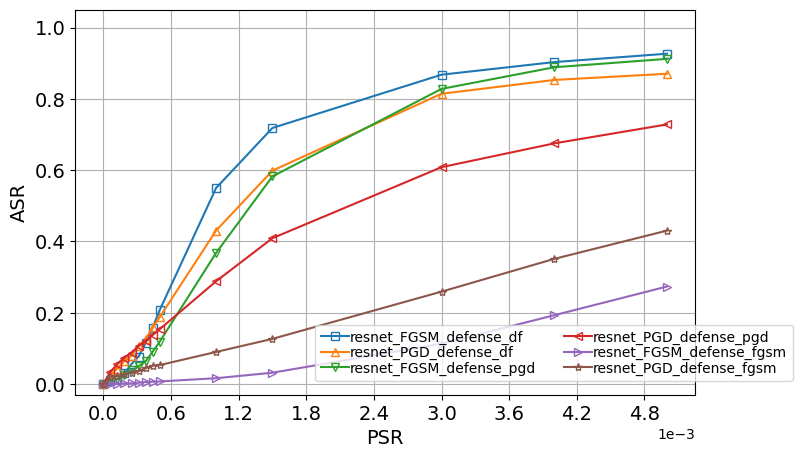

In [4]:
N = 14
atk1 = 'deepfool'
atk2 = 'pgd'
atk3 = 'fgsm'
info = {
    'psr'                     : result['psr'][0:N],
    'resnet_FGSM_defense_df'  : result[f'resnet_fgsm_None_0.001_defense_against_{atk1}'][0:N],
    'resnet_PGD_defense_df'   : result[f'resnet_pgd_4_0.001_defense_against_{atk1}'][0:N],
    'resnet_FGSM_defense_pgd' : result[f'resnet_fgsm_None_0.001_defense_against_{atk2}_4'][0:N],
    'resnet_PGD_defense_pgd'  : result[f'resnet_pgd_4_0.001_defense_against_{atk2}_4'][0:N],
    'resnet_FGSM_defense_fgsm': result[f'resnet_fgsm_None_0.001_defense_against_{atk3}_None'][0:N],
    'resnet_PGD_defense_fgsm' : result[f'resnet_pgd_4_0.001_defense_against_{atk3}_None'][0:N],
}
print ('The psr range is :',info['psr'],sep='\t')
marker_dic = {}
[marker_dic.update({key:marker}) for key,marker in zip(info.keys(),['o','s','^','v','<','>','*','+','x','d'])]
plot_adv_results(config,info,None,'asr',marker_dic = marker_dic)

The psr range is :	[0.000e+00 6.250e-05 1.250e-04 1.875e-04 2.500e-04 3.125e-04 3.750e-04
 4.375e-04 5.000e-04 1.000e-03 1.500e-03 3.000e-03 4.000e-03 5.000e-03]


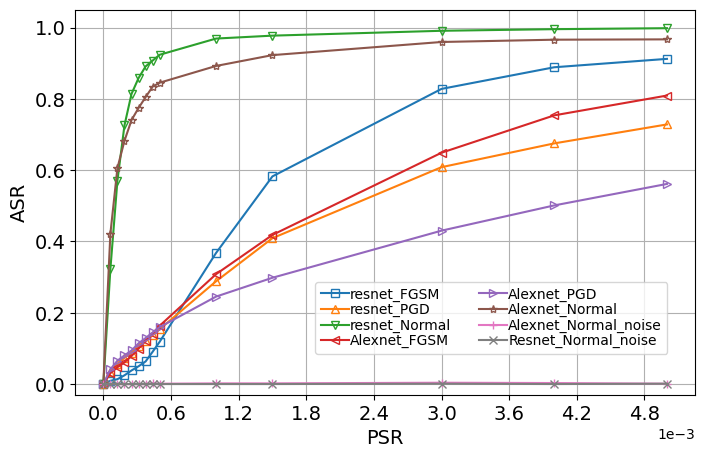

In [12]:
N = 14
atk = 'pgd'
info = {
    'psr'           : result['psr'][0:N],
    'resnet_FGSM'   : result[f'resnet_fgsm_None_0.001_defense_against_{atk}_4'][0:N],
    'resnet_PGD'    : result[f'resnet_pgd_4_0.001_defense_against_{atk}_4'][0:N],
    'resnet_Normal' : result[f'resnet_Normal_None_None_defense_against_{atk}_4'][0:N],
    'Alexnet_FGSM'  : result[f'defult_fgsm_None_0.001_defense_against_{atk}_4'][0:N],
    'Alexnet_PGD'   : result[f'defult_pgd_4_0.001_defense_against_{atk}_4'][0:N],
    'Alexnet_Normal': result[f'defult_Normal_None_None_defense_against_{atk}_4'][0:N],
    'Alexnet_Normal_noise': result['defult_Normal_None_None_defense_against_noise_None'][0:N],
    'Resnet_Normal_noise': result['resnet_Normal_None_None_defense_against_noise_None'][0:N],
}
print ('The psr range is :',info['psr'],sep='\t')
marker_dic = {}
[marker_dic.update({key:marker}) for key,marker in zip(info.keys(),['o','s','^','v','<','>','*','+','x','d'])]
plot_adv_results(config,info,None,'asr',marker_dic = marker_dic)

***Attack different model that trained by different PSR***

The psr range is :	[0.000e+00 6.250e-05 1.250e-04 1.875e-04 2.500e-04 3.125e-04 3.750e-04
 4.375e-04 5.000e-04 1.000e-03 1.500e-03 3.000e-03 4.000e-03]


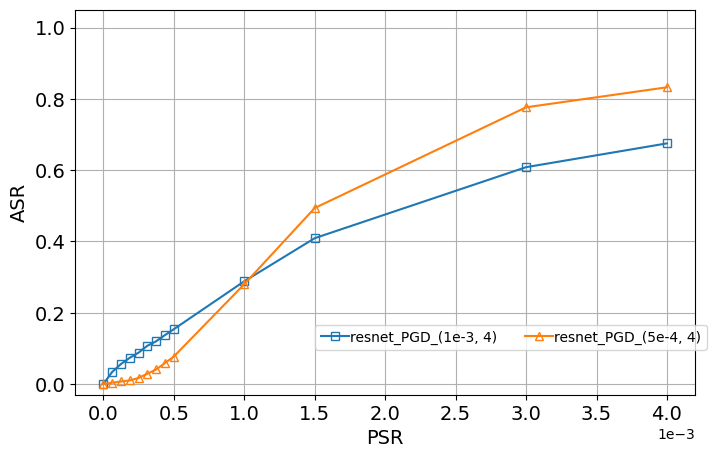

In [11]:
import copy
path = 'resultsMat/adversarial_trainin_alex_resnet.mat'
result = loadmat(path,squeeze_me=True)
result = dict_clean(result)
N = -1
atk = 'pgd'
info = {
    'psr'           : result['psr'][0:N],
    
    'resnet_PGD_(1e-3, 4)'    : result[f'resnet_pgd_4_0.001_defense_against_{atk}_4'][0:N],
    # 'resnet_PGD_(1e-3, 6)'    : result[f'resnet_pgd_4_0.001_defense_against_{atk}_6'][0:N],
    # 'resnet_PGD_(1e-3, 8)'    : result[f'resnet_pgd_4_0.001_defense_against_{atk}_8'][0:N],
    
    'resnet_PGD_(5e-4, 4)'    : result[f'resnet_pgd_4_0.0005_defense_against_{atk}_4'][0:N],
    # 'resnet_PGD_(5e-4, 6)'    : result[f'resnet_pgd_4_0.0005_defense_against_{atk}_6'][0:N],
    # 'resnet_PGD_(5e-4, 8)'    : result[f'resnet_pgd_4_0.0005_defense_against_{atk}_8'][0:N],
}
print ('The psr range is :',info['psr'],sep='\t')
marker_dic = {}
[marker_dic.update({key:marker}) for key,marker in zip(info.keys(),['o','s','^','v','<','>','*','+','x','d'])]
# plot_adv_results(config,copy.deepcopy(info),None,'acc',marker_dic = marker_dic)
plot_adv_results(config,info,None,'asr',marker_dic = marker_dic)

The psr range is :	[0.000e+00 6.250e-05 1.250e-04 1.875e-04 2.500e-04 3.125e-04 3.750e-04
 4.375e-04 5.000e-04 1.000e-03 1.500e-03 3.000e-03 4.000e-03]


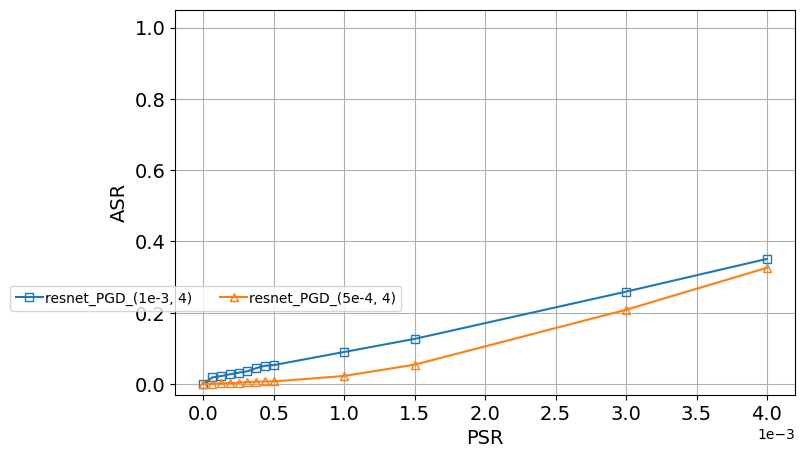

In [10]:
import copy
path = 'resultsMat/adversarial_trainin_alex_resnet.mat'
result = loadmat(path,squeeze_me=True)
result = dict_clean(result)
N = -1
atk = 'fgsm'
info = {
    'psr'           : result['psr'][0:N],
    
    'resnet_PGD_(1e-3, 4)'    : result[f'resnet_pgd_4_0.001_defense_against_{atk}_None'][0:N],
    # 'resnet_PGD_(1e-3, 6)'    : result[f'resnet_pgd_4_0.001_defense_against_{atk}_6'][0:N],
    # 'resnet_PGD_(1e-3, 8)'    : result[f'resnet_pgd_4_0.001_defense_against_{atk}_8'][0:N],
    
    'resnet_PGD_(5e-4, 4)'    : result[f'resnet_pgd_4_0.0005_defense_against_{atk}_None'][0:N],
    # 'resnet_PGD_(5e-4, 6)'    : result[f'resnet_pgd_4_0.0005_defense_against_{atk}_6'][0:N],
    # 'resnet_PGD_(5e-4, 8)'    : result[f'resnet_pgd_4_0.0005_defense_against_{atk}_8'][0:N],
}
print ('The psr range is :',info['psr'],sep='\t')
marker_dic = {}
[marker_dic.update({key:marker}) for key,marker in zip(info.keys(),['o','s','^','v','<','>','*','+','x','d'])]
# plot_adv_results(config,copy.deepcopy(info),None,'acc',marker_dic = marker_dic)
plot_adv_results(config,info,None,'asr',marker_dic = marker_dic)

In [ ]:
psr = loadmat('resultsMat/acc_all_adv_all_l2_pgd.mat',squeeze_me=True)['psr']
print(psr)

pgd_12_defense_against_pgd_12
pgd_7_defense_against_pgd_12
pgd_4_defense_against_pgd_12
pgd_3_defense_against_pgd_12
fgsm_None_defense_against_pgd_12
pgd_2_defense_against_pgd_12
pgd_6_defense_against_pgd_12
pgd_5_defense_against_pgd_12
Normal_defense_against_pgd_12


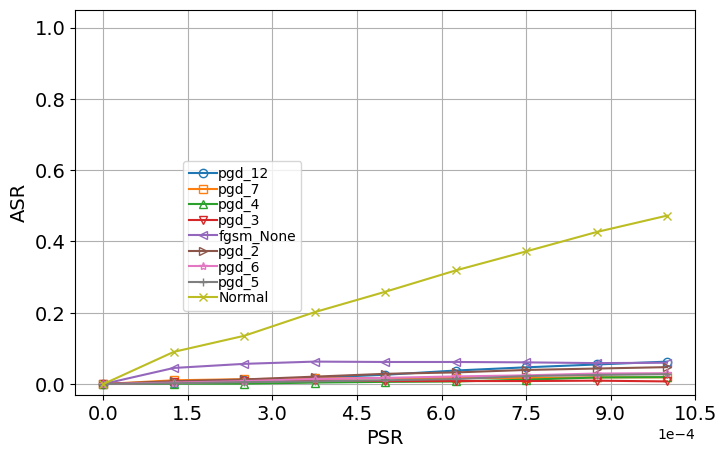

In [122]:
a = loadmat('/media/b218/HOME/Code_ds/Temp/AdvAttackandDefense/resultsMat/acc_all_adv.mat',squeeze_me=True)
info = {}
for key in a.keys():
    if '_defense_against_' in key:
        dfs = key.split('_defense_against_')[0]
        atk = key.split('_defense_against_')[1]
        if atk == 'pgd_12':
            print(key)
            info[dfs] = a[key]
info['psr'] = np.linspace(0,0.001,9)
marker_dic = {}
[marker_dic.update({key:marker}) for key,marker in zip(info.keys(),['o','s','^','v','<','>','*','+','x','d'])]
# plot_adv_results(config,copy.deepcopy(info),None,'acc',marker_dic = marker_dic)
plot_adv_results(config,info,None,'asr',marker_dic = marker_dic)

## Confusion matrix

In [ ]:

path = 'resultsMat/acc_all_adv_all_paper_attack_methods.mat'
result = loadmat(path,squeeze_me=True)
dict_clean(result)
hp_plotter_defense(result,-6,'asr')

## Plot loss of adversarial trained model

In [22]:
random.seed(42)
config.source = 'home_276'
assert config.source != None, 'source should not be None'
train_data, test_data, train_label, test_label = gestureDataLoader.getData(
        config, 'signfi'
        )
X_train, X_test, y_train, y_test = train_test_split(train_data, train_label, test_size=0.1, random_state=42)

Loading data................


In [26]:
from ATKMethods import gen_adv_data
def draw_loss_iter(model, X, y,psr, iter_range: list):
    loss_fn = tf.keras.losses.categorical_crossentropy
    model.compile(loss=loss_fn, optimizer='adam', metrics=['accuracy'])
    loss = []
    X = X
    y = y
    for i in iter_range:
        X_adv = gen_adv_data(X,y,model,'pgd',psr,n_iter = i)
        loss.append(model.evaluate(X_adv,y,verbose=0)[0])
        # yp = model(X_adv)
        # loss.append(np.mean(loss_fn(yp, y)))
        print(f'iter {i} loss is {loss[-1]}')
    return loss        

***Compare the loss of the normal model and adversarial trained model***

In [24]:
iter_range = np.linspace(1,20,20,dtype=int)
# config.N_classes = 276
net = AlexNetTF( config )
model = net.buildModel( choice = 'defult' )
# model.load_weights('SavedModel\Adversarial_robust_model\Normal_defult.h5')
# loss_resnet_norm = draw_loss_iter(model, X_test, y_test, 1.2e-4, iter_range)
''
# model.load_weights('SavedModel/Adversarial_robust_model/robust_adv_training_pgd_psr_0.001_defult_lab_276_niter_4_new.h5')
model.load_weights('SavedModel/Adversarial_robust_model/robust_adv_training_pgd_psr_0.001_defult_home_276_niter_4_new.h5')
loss_resnet_adv = draw_loss_iter(model, X_test, y_test, 1.2e-5, iter_range)

iter 1 loss is [6.118585109710693]
iter 2 loss is [6.118585109710693, 6.118570804595947]
iter 3 loss is [6.118585109710693, 6.118570804595947, 6.118564128875732]
iter 4 loss is [6.118585109710693, 6.118570804595947, 6.118564128875732, 6.118583679199219]
iter 5 loss is [6.118585109710693, 6.118570804595947, 6.118564128875732, 6.118583679199219, 6.118570804595947]
iter 6 loss is [6.118585109710693, 6.118570804595947, 6.118564128875732, 6.118583679199219, 6.118570804595947, 6.118574619293213]
iter 7 loss is [6.118585109710693, 6.118570804595947, 6.118564128875732, 6.118583679199219, 6.118570804595947, 6.118574619293213, 6.118582725524902]
iter 8 loss is [6.118585109710693, 6.118570804595947, 6.118564128875732, 6.118583679199219, 6.118570804595947, 6.118574619293213, 6.118582725524902, 6.118575096130371]
iter 9 loss is [6.118585109710693, 6.118570804595947, 6.118564128875732, 6.118583679199219, 6.118570804595947, 6.118574619293213, 6.118582725524902, 6.118575096130371, 6.118574142456055]
i

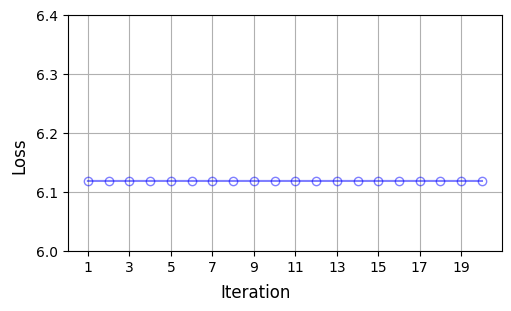

In [28]:
from matplotlib.lines import Line2D
fig, ax = plt.subplots(1, 1, constrained_layout=True)

#set figure size
fig.set_figheight(3)
fig.set_figwidth(5)

ax.plot(iter_range,loss_resnet_adv,'bo-',
        fillstyle = Line2D.fillStyles[-1],
        alpha = 0.5,
        )
plt.xticks(np.arange(1, 21, step=2))
plt.ylim((6,6.4))
# ax.set_title('Adversarial Training Model')

fig.supylabel('Loss')
fig.supxlabel('Iteration')
plt.grid()

plt.savefig('RESULTS_FIGS/loss_iter.pdf')
plt.show()

In [ ]:
net = AlexNetTF( config )
model = net.buildModel( choice = 'defult' )
model.load_weights('SavedModel/Adversarial_robust_model/Normal_defult.h5')
draw_loss_iter(model, X_test, y_test,1.2e-4, [4])
model.load_weights('SavedModel/Adversarial_robust_model/robust_adv_training_pgd_psr_0.001_defult_lab_276_niter_4_new.h5')
draw_loss_iter(model, X_test, y_test,1.2e-4, [4])

In [ ]:
print('The X axis is the psr for Guassian noise and Y axis is the PSR for FGSM or PGD attack')
model.load_weights('SavedModel/Adversarial_robust_model/robust_adv_training_pgd_psr_0.0005_resnet_lab_276_niter_4_new.h5')
draw_loss(model,X_train[0:1],y_train[0:1],0.001)
model.load_weights('SavedModel/Adversarial_robust_model/Normal_resnet.h5')
draw_loss(model,X_train[0:1],y_train[0:1],0.001)

# Black box Attack (UAP)

### In-domain UAP attack

The in domain results stored in file `resultsMat/UAP_cross_model_0to0.02.mat`, keys `Attacker model name _UAPName_ Victime model name`

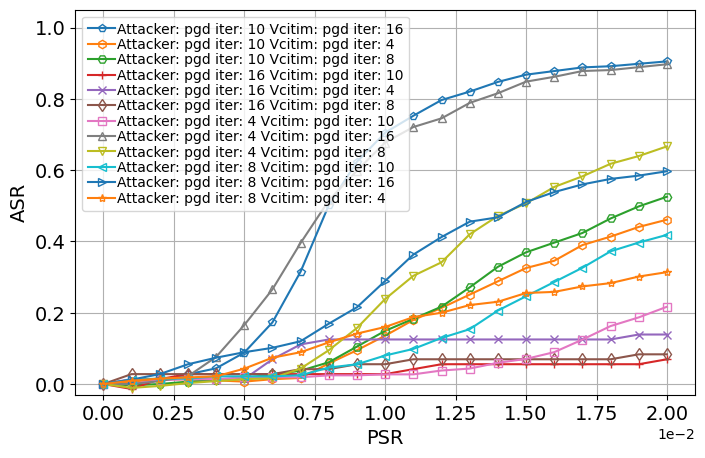

In [4]:
psr = np.linspace(0,2e-2,21)
re = loadmat('resultsMat/UAP_cross_model_0to0.02.mat',squeeze_me=True)
legend = {}
info = {'psr':psr}
i = 0
for atk_model_METHOD in ['pgd']:
    for key in re.keys():
        try:
            ATK_METHOD = key.split('_')[1]
            ATK_PSR = key.split('_')[3]
            ATK_iter = key.split('_')[2]
            VIC_METHOD = key.split('_UAPName_')[1].split('_')[1]
            VIC_PSR = key.split('_UAPName_')[1].split('_')[3]
            VIC_iter = key.split('_UAPName_')[1].split('_')[2]
            if atk_model_METHOD in key:
                if ATK_METHOD == VIC_METHOD and ATK_PSR == VIC_PSR and ATK_iter != VIC_iter:
                    # print(key,'\n',re[key])
                    legend[key] = 'Attacker: '+ATK_METHOD+' iter: '+ATK_iter+' Vcitim: '+VIC_METHOD+' iter: '+VIC_iter
                    info[key] = re[key]
                    i += 1
            if i >50:
                break
        except:
            # print(key)
            continue

marker_dic = {}
[marker_dic.update({key:marker}) for key,marker in zip(info.keys(),['o','s','^','v','<','>','*','+','x','d','p','h','H','D','P','X','1','2','3','4','8','|','_'])]
plot_adv_results(config,info,None,'asr',marker_dic = marker_dic, legend = legend)

defult_fgsm_None_0.001_UAPName_Normal
defult_fgsm_None_0.005_UAPName_Normal
defult_fgsm_None_5e-05_UAPName_Normal
defult_fgsm_None_0.003_UAPName_Normal
defult_fgsm_None_0.00025_UAPName_Normal
defult_fgsm_None_0.00075_UAPName_Normal
defult_fgsm_None_0.0001_UAPName_Normal
Normal_UAPName_Normal
[0.982 0.007 0.005 0.005 0.005 0.005 0.005 0.005 0.005 0.005 0.005 0.005
 0.005 0.005 0.005 0.005 0.005 0.005 0.005 0.005 0.005]
0.9478824


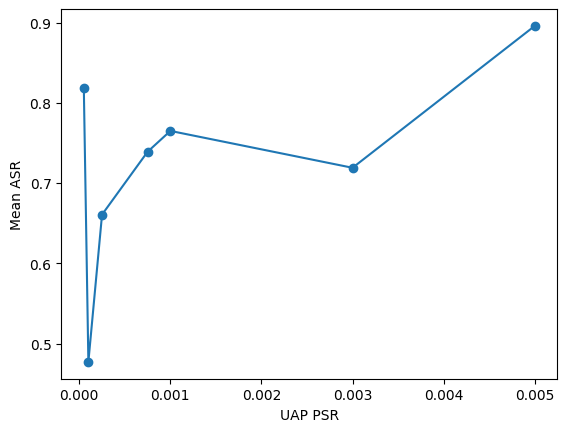

In [83]:
'defult_fgsm_None_0.00075_UAPName_defult_fgsm_None_0.003'
from scipy.io import loadmat, savemat
import numpy as np
import copy
import matplotlib.pyplot as plt
# print(psr_rec.keys())
def extractor( name ):
    model_name = name.split('_')[0]
    at_method = name.split('_')[1]
    n_iter = name.split('_')[2]
    psr = float(name.split('_')[3])
    UAP_model_name = name.split('_')[5]
    UAP_at_method = name.split('_')[6]
    UAP_n_iter = name.split('_')[7]
    UAP_psr = float(name.split('_')[8])
    return model_name,at_method,n_iter,psr,UAP_model_name,UAP_at_method,UAP_n_iter,UAP_psr

psr_rec = loadmat('resultsMat/UAP_cross_model_0to0.02.mat',squeeze_me=True)
testing_psr = psr_rec['psr']
info = {}
for key in psr_rec.keys():
    if key.startswith('__'):
        continue
    try:
        model_name,at_method,n_iter,psr,UAP_model_name,UAP_at_method,UAP_n_iter,UAP_psr = extractor(key)
        # print('a')
    except:
        if key != 'psr' and key.split('_UAPName_')[1] == 'Normal' and 'pgd' not in key:
            print(key)
            info[key] = psr_rec[key]
    if 'niter' in key:
        continue
    if at_method != 'fgsm':
        continue
    if UAP_at_method != 'fgsm':
        continue
    if UAP_at_method == 'pgd' and UAP_n_iter != '8':
        continue
    if 0.005 != psr:
        continue
    np.set_printoptions(precision=3)
    
    # info[key] = psr_rec[key]
# info['psr'] = testing_psr
# marker_dic = {}
# [marker_dic.update({key:marker}) for key,marker in zip(info.keys(),['o','s','^','v','<','>','*','+','x','d'])]
# plot_adv_results(config,info,None,'asr',marker_dic = marker_dic)
mean_asr = []
UAP_psr = []
for key,acc in info.items():
    if key.startswith('__'):
        continue
    if key == 'psr':
        continue
    if key.split('_')[0] == 'pgd':
        continue
    # UAP_psr.append(extractor(key)[7])
    if key.split('_UAPName_')[0] == 'Normal':
        print(acc)
        print(      np.mean((acc[0] - acc)/acc[0])  )
        continue
    UAP_psr.append(float(key.split('_')[3]))
    # print(key,acc)
    mean_asr.append(np.mean(((acc[0] - acc)/acc[0])))
# import pandas as pd
# info.pop['psr']
# print_asr_acc(info)
UAP_psr = np.array(UAP_psr)
mean_asr = np.array(mean_asr)
idx = np.argsort(UAP_psr)
plt.plot(UAP_psr[idx], mean_asr[idx],'o-')
plt.xlabel('UAP PSR')
plt.ylabel('Mean ASR')
plt.show()

### Cross-domain UAP Attacks

Key pattern: `Attacker model name _atk_ victim model name`

<Figure size 800x600 with 0 Axes>

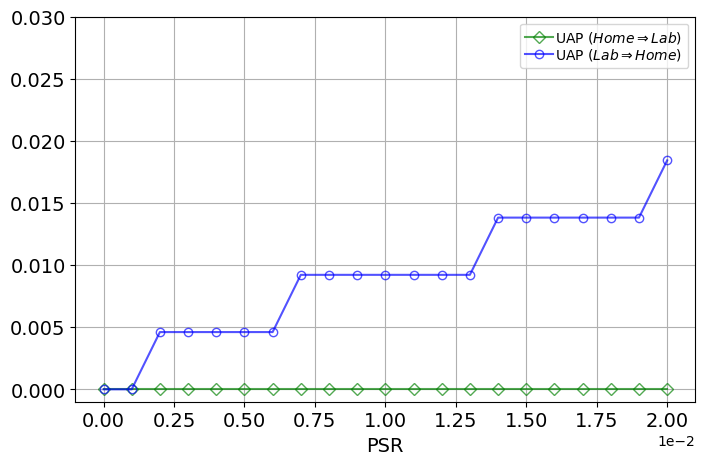

In [3]:
def get_info_from_key(key):
    if 'Surrogate_Normal_home' not in key and 'Surrogate_Normal_lab' not in key:
        info_list = key.split('_')
        UAP_psr = float(info_list[1])
        UAP_iter = int(info_list[3])
        vic_psr = float(info_list[7])
        vic_iter = int(info_list[9])
        return UAP_psr,UAP_iter,vic_psr,vic_iter
    elif 'Surrogate_Normal_home' in key or 'Surrogate_Normal_lab' in key:
        info_list = key.split('_')
        UAP_model_name = 'Surrogate_Normal_home'
        vic_psr = float(info_list[6])
        vic_iter = int(info_list[8])
        return UAP_model_name, vic_psr, vic_iter
def get_plot_style(*args):
    marker_dic = {}
    color_dic = {}
    for info in args:
        # [marker_dic.update({key:marker}) for key,marker in zip(sorted(info.keys()),['o','o','o','s','s','s','^','^','^','^','^',])]
        # [color_dic.update({key:color}) for key,color in zip(sorted(info.keys()),['b','r','g','b','r','g','b','r','g',])]
        
        [marker_dic.update({key:marker}) for key,marker in zip(sorted(info.keys()),['D','o',])]
        [color_dic.update({key:color}) for key,color in zip(sorted(info.keys()),['g','b','r','g',])]
    return marker_dic,color_dic
results = dict_clean(loadmat('resultsMat/Adversarial_training_results/UAP_Cross_domain_results_normal_surro_train_lab_to_home.mat',squeeze_me=True))
psr = np.linspace(0,2e-2,21)
legend = {}
marker_dic,color_dic = {},{}
info = {'psr':psr}
# i = 0
for key in results.keys():
    try:
        UAP_model_name, vic_psr, vic_iter = get_info_from_key(key)

        if vic_psr > 0.003 or vic_iter > 10:
            continue
        if vic_iter == 6:
            continue
        if vic_iter == 4 and vic_psr == 0.001:
            
            legend[key] = 'UAP ($Lab \Rightarrow Home$)'
            info[key] = results[key].min(axis=0)
    except:
        print(key)
        continue
results = dict_clean(loadmat('resultsMat/Adversarial_training_results/UAP_Cross_domain_results_normal_surro_train.mat',squeeze_me=True))
info_1 = {'psr':psr}
for key in results.keys():
    try:
        UAP_model_name, vic_psr, vic_iter = get_info_from_key(key)
        if vic_psr > 0.003 or vic_iter > 10:
            continue
        if vic_iter == 4 and vic_psr == 0.001:
            legend[key] = 'UAP ($Home \Rightarrow Lab$) '
            info_1[key] = results[key].max(axis=0)
    except:
        print(key)
        continue
to_plot = {**info,**info_1}
marker_dic,color_dic = get_plot_style(to_plot)
# 'BB Defense results (victim lab)'
# plot_adv_results(config,[info_1,info,],'BB cross-domain defence subplot results','asr',
#                  marker_dic = marker_dic, color_dic = color_dic, legend = legend, sub_plot_layout = (2,1,1),
#                  title = ['Home to Lab','Lab to Home',],ylim = [-0.01,0.4])
plot_adv_results(config,to_plot,'BB cross-domain defence subplot results','asr',
                 marker_dic = marker_dic, color_dic = color_dic, legend = legend, alpha = 0.68,
                #  title = ['Home to Lab','Lab to Home'],
                 ylim = [-0.001,0.03])

In [6]:
legend

{'Surrogate_Normal_lab_atk_home_PSR_0.001_iter_8': 'PSR: 0.001 iter: 8',
 'Surrogate_Normal_home_atk_lab_PSR_0.001_iter_8': '  PSR: 0.001 iter: 8'}

In [30]:
import copy
results = dict_clean(loadmat('resultsMat/Adversarial_training_results/UAP_Cross_domain_results_normal_surro_train_lab_to_home.mat',squeeze_me=True))
new_results = copy.deepcopy(results)
for key in results.keys():
    # list_ = key.split('_')
    # results[key]
    # print(type(key))
    replace_key = key.replace('home_atk_lab','lab_atk_home')
    new_results[replace_key] = new_results.pop(key)
    # remove the key
    # results.pop(key)
savemat('resultsMat/Adversarial_training_results/UAP_Cross_domain_results_normal_surro_train_lab_to_home.mat',new_results)

In [35]:
marker_dic.keys()

dict_keys(['psr', 'Surrogate_Normal_home_atk_lab_PSR_0.00075_iter_10', 'Surrogate_Normal_home_atk_lab_PSR_0.00075_iter_4', 'Surrogate_Normal_home_atk_lab_PSR_0.00075_iter_8', 'Surrogate_Normal_home_atk_lab_PSR_0.001_iter_10', 'Surrogate_Normal_home_atk_lab_PSR_0.001_iter_4', 'Surrogate_Normal_home_atk_lab_PSR_0.001_iter_8', 'Surrogate_Normal_home_atk_lab_PSR_0.003_iter_10', 'Surrogate_Normal_home_atk_lab_PSR_0.003_iter_4', 'Surrogate_Normal_home_atk_lab_PSR_0.003_iter_8'])

In [5]:
avg_mtc = []
for key,val in info_1.items():
    if key == 'psr':
        continue
    mtc = (val[0] - val)/val[0]
    avg_mtc.append( np.mean(mtc))
    print(key, val.mean(),)
print('The ASR of the worst case is ',np.max(avg_mtc))
print('The ASR of the best case is ',np.min(avg_mtc))

Surrogate_Normal_home_atk_lab_PSR_0.00075_iter_4 0.69349277
Surrogate_Normal_home_atk_lab_PSR_0.001_iter_4 0.8846153
Surrogate_Normal_home_atk_lab_PSR_0.00075_iter_10 0.7603964
Surrogate_Normal_home_atk_lab_PSR_0.001_iter_8 0.72387415
Surrogate_Normal_home_atk_lab_PSR_0.003_iter_4 0.69295406
Surrogate_Normal_home_atk_lab_PSR_0.001_iter_10 0.6578324
Surrogate_Normal_home_atk_lab_PSR_0.00075_iter_8 0.7279681
Surrogate_Normal_home_atk_lab_PSR_0.003_iter_8 0.6956475
Surrogate_Normal_home_atk_lab_PSR_0.003_iter_10 0.7399267
The ASR of the worst case is  0.12671277
The ASR of the best case is  0.0
